First 5 records:
   Area  Bedrooms  Age    Price
0   850         1   18  3600000
1   900         1   15  3850000
2   950         2   12  4200000
3  1000         2   20  4350000
4  1050         2   10  4650000

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      40 non-null     int64
 1   Bedrooms  40 non-null     int64
 2   Age       40 non-null     int64
 3   Price     40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB
None

LINEAR REGRESSION PERFORMANCE
MAE       : 61407.84948003979
MSE       : 4889166822.857321
RMSE      : 69922.5773470724
R2 Score  : 0.9989747151719818


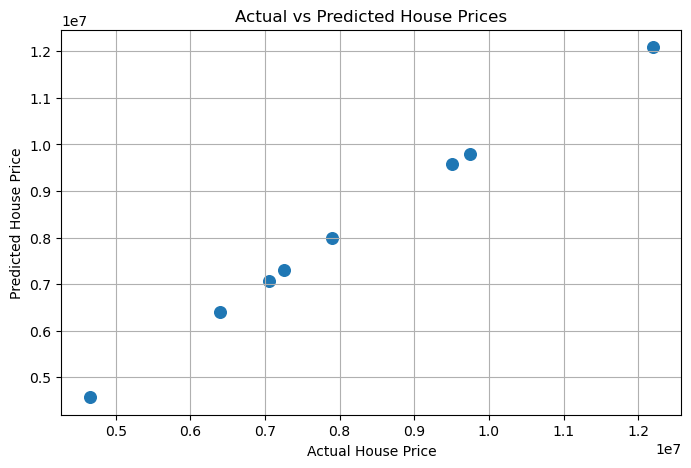


GRADIENT DESCENT PERFORMANCE
Final Cost: 15579845411.44437
MAE       : 80333.7139024447
MSE       : 9946184049.976578
RMSE      : 99730.5572529131
R2 Score  : 0.9979142312028622


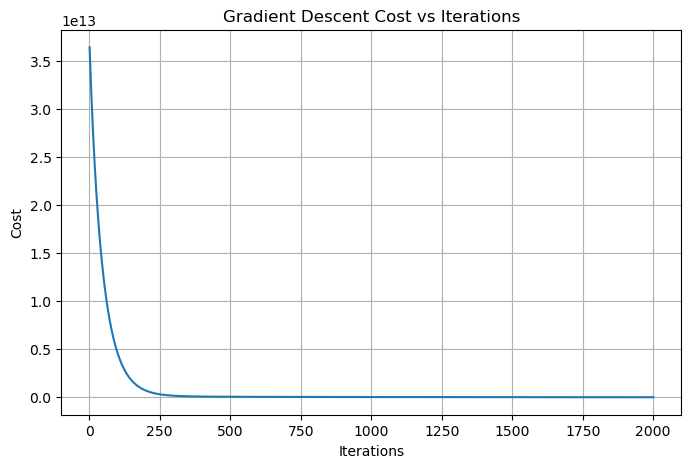

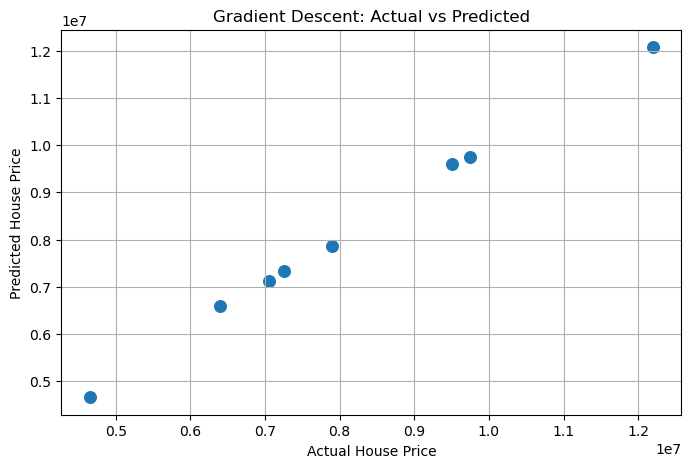

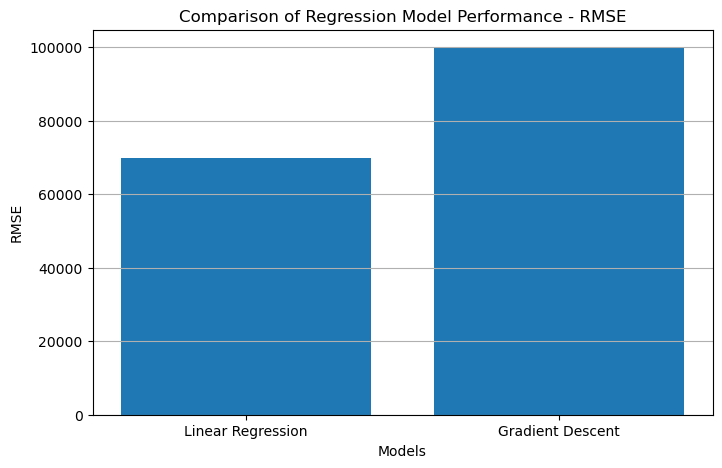

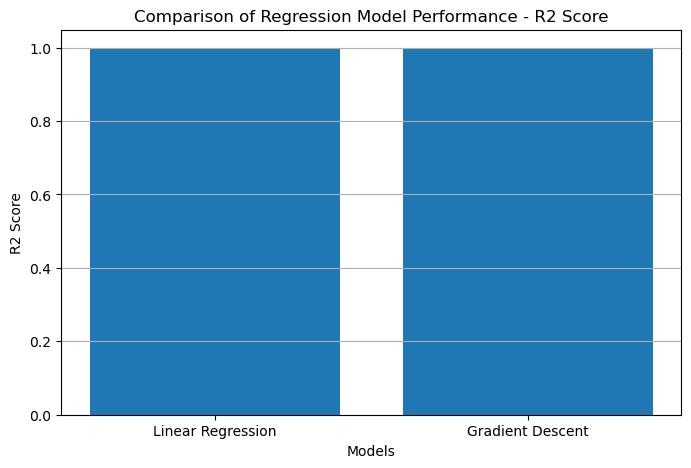


FINAL MODEL COMPARISON
            Model          MAE          MSE         RMSE  R2 Score
Linear Regression 61407.849480 4.889167e+09 69922.577347  0.998975
 Gradient Descent 80333.713902 9.946184e+09 99730.557253  0.997914


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==========================================
# 1. LOAD DATASET
# ==========================================

data = pd.read_csv("house_price.csv")

print("First 5 records:")
print(data.head())

print("\nDataset Information:")
print(data.info())


# ==========================================
# 2. SELECT FEATURES AND TARGET
# ==========================================

X = data[["Area", "Bedrooms", "Age"]]
y = data["Price"]


# ==========================================
# 3. TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================================
# 4. LINEAR REGRESSION MODEL
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)


# ==========================================
# 5. LINEAR REGRESSION PERFORMANCE
# ==========================================

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


print("\n==========================================")
print("LINEAR REGRESSION PERFORMANCE")
print("==========================================")

print("MAE       :", linear_mae)
print("MSE       :", linear_mse)
print("RMSE      :", linear_rmse)
print("R2 Score  :", linear_r2)


# ==========================================
# 6. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    linear_predictions,
    s=70
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)
plt.show()


# ==========================================
# 7. PREPARE DATA FOR GRADIENT DESCENT
# ==========================================

X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)

y_train_np = y_train.values.reshape(-1, 1).astype(float)
y_test_np = y_test.values.reshape(-1, 1).astype(float)


# ==========================================
# 8. FEATURE STANDARDIZATION
# ==========================================

X_mean = X_train_np.mean(axis=0)
X_std = X_train_np.std(axis=0)

X_train_scaled = (
    X_train_np - X_mean
) / X_std

X_test_scaled = (
    X_test_np - X_mean
) / X_std


# ==========================================
# 9. ADD INTERCEPT COLUMN
# ==========================================

X_train_gd = np.c_[
    np.ones((X_train_scaled.shape[0], 1)),
    X_train_scaled
]

X_test_gd = np.c_[
    np.ones((X_test_scaled.shape[0], 1)),
    X_test_scaled
]


# ==========================================
# 10. INITIALIZE GRADIENT DESCENT
# ==========================================

theta = np.zeros(
    (X_train_gd.shape[1], 1)
)

learning_rate = 0.01

iterations = 2000

m = len(y_train_np)

cost_history = []


# ==========================================
# 11. GRADIENT DESCENT
# ==========================================

for i in range(iterations):

    # Calculate predictions
    predictions = X_train_gd.dot(theta)

    # Calculate error
    error = predictions - y_train_np

    # Calculate cost
    cost = (
        1 / (2 * m)
    ) * np.sum(error ** 2)

    cost_history.append(cost)

    # Calculate gradients
    gradients = (
        1 / m
    ) * X_train_gd.T.dot(error)

    # Update parameters
    theta = theta - learning_rate * gradients


# ==========================================
# 12. GRADIENT DESCENT PREDICTIONS
# ==========================================

gd_predictions = X_test_gd.dot(theta)


# ==========================================
# 13. GRADIENT DESCENT PERFORMANCE
# ==========================================

gd_mae = mean_absolute_error(
    y_test_np,
    gd_predictions
)

gd_mse = mean_squared_error(
    y_test_np,
    gd_predictions
)

gd_rmse = np.sqrt(gd_mse)

gd_r2 = r2_score(
    y_test_np,
    gd_predictions
)


print("\n==========================================")
print("GRADIENT DESCENT PERFORMANCE")
print("==========================================")

print("Final Cost:", cost_history[-1])

print("MAE       :", gd_mae)

print("MSE       :", gd_mse)

print("RMSE      :", gd_rmse)

print("R2 Score  :", gd_r2)


# ==========================================
# 14. GRADIENT DESCENT CONVERGENCE GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    cost_history
)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title(
    "Gradient Descent Cost vs Iterations"
)

plt.grid(True)

plt.show()


# ==========================================
# 15. GRADIENT DESCENT ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_np,
    gd_predictions,
    s=70
)

plt.xlabel("Actual House Price")

plt.ylabel(
    "Predicted House Price"
)

plt.title(
    "Gradient Descent: Actual vs Predicted"
)

plt.grid(True)

plt.show()


# ==========================================
# 16. MODEL PERFORMANCE COMPARISON
# ==========================================

models = [
    "Linear Regression",
    "Gradient Descent"
]

rmse_values = [
    linear_rmse,
    gd_rmse
]

r2_values = [
    linear_r2,
    gd_r2
]


# RMSE Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    rmse_values
)

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.title(
    "Comparison of Regression Model Performance - RMSE"
)

plt.grid(axis="y")

plt.show()


# R2 Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    r2_values
)

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.title(
    "Comparison of Regression Model Performance - R2 Score"
)

plt.grid(axis="y")

plt.show()


# ==========================================
# 17. FINAL COMPARISON TABLE
# ==========================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Gradient Descent"
    ],

    "MAE": [
        linear_mae,
        gd_mae
    ],

    "MSE": [
        linear_mse,
        gd_mse
    ],

    "RMSE": [
        linear_rmse,
        gd_rmse
    ],

    "R2 Score": [
        linear_r2,
        gd_r2
    ]

})


print("\n==========================================")
print("FINAL MODEL COMPARISON")
print("==========================================")

print(
    comparison.to_string(index=False)
)